In [16]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pydicom as dcm
from pydicom.data import get_testdata_file

import sys, pickle, os, torch, cv2

# replace this path with path to GMIC
sys.path.append("./GMIC/")

from src.data_loading import loading
from src.modeling import gmic as gmic

In [17]:
# path = get_testdata_file("CT_small.dcm") # download sample dataset
path = "../Data/BSC-DBT/DBT-P00538/01-01-2000-DBT-S01986-MAMMO screening digital bilateral-71001/14154.000000-69041/1-1.dcm"

ds = dcm.dcmread(path, force=True) # dicom dataset
# print(ds.elements)
print(ds.ViewPosition)
print(ds.PatientOrientation[1])
print(ds.XRay3DAcquisitionSequence[0].FieldOfViewHorizontalFlip[0])

CC
L
N


<class 'pydicom.dataset.FileDataset'>
<class 'numpy.ndarray'>
0
687
(2457, 1996)
65


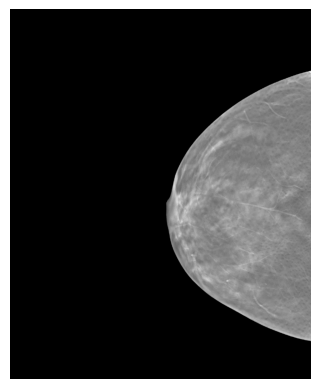

In [25]:
idx = 2
arr = ds.pixel_array # numpy.ndarray
pngImage = arr[idx]

plt.imshow(pngImage, cmap="gray")
plt.axis("off")
# plt.savefig("output.png")

print(type(ds))
print(type(pngImage))
print(np.min(pngImage))
print(np.max(pngImage))
print(pngImage.shape)
print(len(arr))

MLO
HL
N


(-0.5, 1995.5, 2456.5, -0.5)

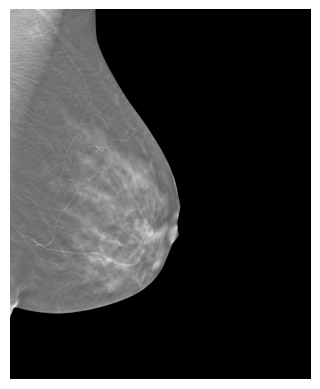

In [19]:
# path = get_testdata_file("CT_small.dcm") # download sample dataset
path = "../Data/BSC-DBT/DBT-P00538/01-01-2000-DBT-S01986-MAMMO screening digital bilateral-71001/14155.000000-36016/1-1.dcm"

ds = dcm.dcmread(path, force=True) # dicom dataset
# print(ds.elements)
print(ds.ViewPosition)
print(ds.PatientOrientation[1])
print(ds.XRay3DAcquisitionSequence[0].FieldOfViewHorizontalFlip[0])

arr = ds.pixel_array # numpy.ndarray
pngImage = arr[2]

plt.imshow(pngImage, cmap="gray")
plt.axis("off")

MLO
FL
N


(-0.5, 1995.5, 2456.5, -0.5)

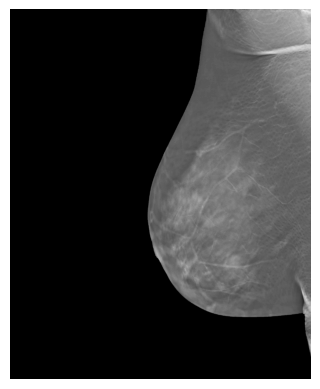

In [20]:
# path = get_testdata_file("CT_small.dcm") # download sample dataset
path = "../Data/BSC-DBT/DBT-P00538/01-01-2000-DBT-S01986-MAMMO screening digital bilateral-71001/14156.000000-08630/1-1.dcm"

ds = dcm.dcmread(path, force=True) # dicom dataset
# print(ds.elements)
print(ds.ViewPosition)
print(ds.PatientOrientation[1])
print(ds.XRay3DAcquisitionSequence[0].FieldOfViewHorizontalFlip[0])

arr = ds.pixel_array # numpy.ndarray
pngImage = arr[2]

plt.imshow(pngImage, cmap="gray")
plt.axis("off")

CC
L
N


(-0.5, 1995.5, 2456.5, -0.5)

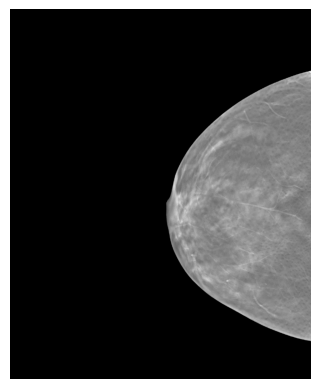

In [21]:
# path = get_testdata_file("CT_small.dcm") # download sample dataset
path = "../Data/BSC-DBT/DBT-P00538/01-01-2000-DBT-S01986-MAMMO screening digital bilateral-71001/14157.000000-86898/1-1.dcm"

ds = dcm.dcmread(path, force=True) # dicom dataset
# print(ds.elements)
print(ds.ViewPosition)
print(ds.PatientOrientation[1])
print(ds.XRay3DAcquisitionSequence[0].FieldOfViewHorizontalFlip[0])

arr = ds.pixel_array # numpy.ndarray
pngImage = arr[2]

plt.imshow(pngImage, cmap="gray")
plt.axis("off")

<class 'numpy.ndarray'>
(480, 640, 4)


{'horizontal_flip': 'NO', 'L-MLO': ['3_L-MLO'], 'L-CC': ['3_L-CC'], 'R-MLO': ['3_R-MLO'], 'R-CC': ['3_R-CC'], 'cancer_label': {'benign': 0, 'right_benign': 0, 'malignant': 0, 'left_benign': 0, 'unknown': 0, 'right_malignant': 0, 'left_malignant': 0}, 'window_location': {'L-CC': [(188, 2352, 0, 949)], 'R-CC': [(293, 2300, 1010, 1890)], 'L-MLO': [(0, 2395, 919, 1890)], 'R-MLO': [(0, 2434, 0, 1000)]}, 'rightmost_points': {'L-CC': [((1155, 1155), 898)], 'R-CC': [((815, 816), 830)], 'L-MLO': [((798, 2244), 970)], 'R-MLO': [((811, 2283), 1000)]}, 'bottommost_points': {'L-CC': [(2113, (100, 133))], 'R-CC': [(1956, (101, 105))], 'L-MLO': [(2344, (864, 870))], 'R-MLO': [(2383, (900, 900))]}, 'distance_from_starting_side': {'L-CC': [0], 'R-CC': [0], 'L-MLO': [919], 'R-MLO': [890]}, 'best_center': {'L-CC': [(1082, -63)], 'R-CC': [(1003, -131)], 'L-MLO': [(871, 9)], 'R-MLO': [(910, 39)]}}
3_L-CC
<class 'numpy.ndarray'>
0.0
914.0
(2164, 949)


/opt/homebrew/Caskroom/miniforge/base/envs/learning/lib/python3.11/site-packages/imageio/plugins/pillow.py:304: UserWarning: Loading 16-bit (uint16) PNG as int32 due to limitations in pillow's PNG decoder. This will be fixed in a future version of pillow which will make this warning dissapear.
  warnings.warn(


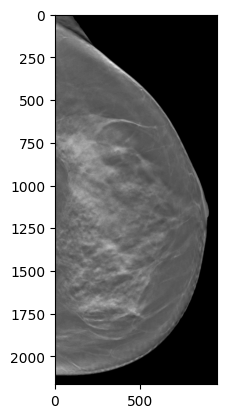

In [28]:
with open("../Data/BSC-DBT/output/data.pkl", "rb") as f:
    exam_list = pickle.load(f)

print(exam_list[0])
datum = exam_list[0]
view = "L-CC"
short_file_path = datum[view][0]
print(short_file_path)

loaded_image = loading.load_image(
                    image_path=os.path.join("../Data/BSC-DBT/output/cropped_images/", short_file_path + ".png"),
                    view=view, horizontal_flip=datum["horizontal_flip"])

print(type(loaded_image))
print(np.min(loaded_image))
print(np.max(loaded_image))
print(loaded_image.shape)

plt.imshow(loaded_image, cmap="gray")

In [30]:
best_center = datum["best_center"][view][0]

loaded_image = loading.process_image(loaded_image, view, best_center)

(2944, 1920)
4.940564


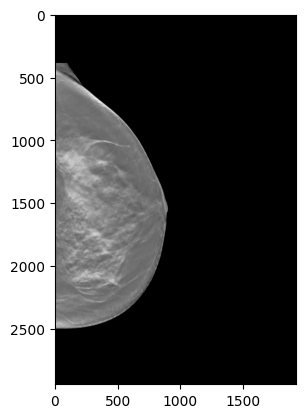

In [31]:
print(loaded_image.shape)
print(np.max(loaded_image))
plt.imshow(loaded_image, cmap="Greys_r")
# plt.axis("off")
plt.savefig("mammoOriginal.png")
plt.show()

In [32]:
parameters = {
        "device_type":"cpu",
        "cam_size": (46, 30),
        "K": 6,
        "crop_shape": (256, 256),
        "percent_t": 0.02, 
        "post_processing_dim": 256,
        "num_classes": 2
    }

model = gmic.GMIC(parameters)

In [55]:
model.load_state_dict(torch.load("models/sample_model_2.p", map_location="cpu"), strict=False)

_IncompatibleKeys(missing_keys=[], unexpected_keys=['shared_rep_filter.weight'])

In [56]:
tensor_batch = torch.Tensor(np.expand_dims(np.expand_dims(loaded_image, 0), 0).copy())
output = model(tensor_batch)
pred_numpy = output.data.cpu().numpy()
begnin_pred = pred_numpy[0,0]
malignant_pred = pred_numpy[0, 1]

In [57]:
print("begnin prediction = {}".format(begnin_pred))
print("malignant prediction = {}".format(malignant_pred))

begnin prediction = 0.15074197947978973
malignant prediction = 0.005433670245110989


/var/folders/d7/q72cpd5d6bv6knpx85s28lq80000gn/T/ipykernel_45428/3984686315.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  alpha_red = plt.cm.get_cmap('Reds')


(46, 30)
2.1223205e-07
0.43695527
[[1.64001453e-04 5.27548546e-04 9.75068018e-04 ... 1.48243206e-02
  3.88746476e-03 1.36229943e-03]
 [8.18664557e-05 2.20597518e-04 4.22657700e-04 ... 3.16259861e-02
  1.23050045e-02 3.74678546e-03]
 [3.59310980e-05 1.18060627e-04 4.17665782e-04 ... 2.65732296e-02
  2.72535682e-02 6.25288673e-03]
 ...
 [5.65083115e-04 1.11139601e-03 4.23485501e-04 ... 1.52684040e-02
  3.16838920e-02 9.68558993e-03]
 [2.04780426e-05 5.04891541e-05 5.36893604e-05 ... 3.52337142e-03
  4.03424772e-03 2.61739967e-03]
 [6.26989959e-06 9.11004372e-06 1.84413620e-05 ... 3.24632623e-04
  5.50925033e-04 2.22401301e-04]]
(2944, 1920)
2.1569508e-07
0.4344573
[[1.6400145e-04 1.6400145e-04 1.6400145e-04 ... 1.3622994e-03
  1.3622994e-03 1.3622994e-03]
 [1.6400145e-04 1.6400145e-04 1.6400145e-04 ... 1.3622994e-03
  1.3622994e-03 1.3622994e-03]
 [1.6400145e-04 1.6400145e-04 1.6400145e-04 ... 1.3622994e-03
  1.3622994e-03 1.3622994e-03]
 ...
 [6.2698996e-06 6.2698996e-06 6.2698996e-06 .

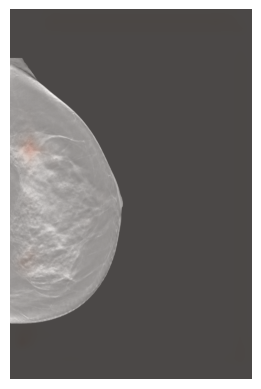

In [66]:
saliency_maps = model.saliency_map.data.cpu().numpy()
malignant_saliency_map = saliency_maps[0,1,:,:]
alphas = np.abs(np.linspace(0, 0.95, 259))

alpha_red = plt.cm.get_cmap('Reds')
print(malignant_saliency_map.shape)
print(np.min(malignant_saliency_map))
print(np.max(malignant_saliency_map))
print(malignant_saliency_map)
# plt.imshow(malignant_saliency_map, alpha=0.3, cmap=alpha_red, clim=[0.0, 1.0])
# plt.axis("off")
# plt.savefig("mammoResult.png")

malignant_saliency_map = cv2.resize(malignant_saliency_map, (1920, 2944))
print(malignant_saliency_map.shape)
print(np.min(malignant_saliency_map))
print(np.max(malignant_saliency_map))
print(malignant_saliency_map)

plt.figure()
plt.imshow(loaded_image, cmap="Greys_r")
plt.imshow(malignant_saliency_map, alpha=0.3, cmap=alpha_red, clim=[0.0, 1.0])
plt.axis("off")
# plt.savefig("mammoResult.png")
plt.show()